In [1]:
import os
import warnings

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import scienceplots
plt.style.use("science")
import tol_colors as tc

cset = tc.colorsets["medium_contrast"]

# Path to result data (relative to notebooks/ directory)
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath("")), "result", "stat")

# Methods to compare
METHODS = {"cls": "AS", "thd": "DT"}

In [2]:
def load_data(problem, size, method, penalties, projection=False):
    """Load CSV data for a method across all penalty values."""
    size_str = str(size) if problem == "rb" else f"{size}-{size}"
    suffix = "-p" if projection else ""
    data = {}
    for p in penalties:
        filename = f"{problem}_{method}{p}_{size_str}{suffix}.csv"
        csv_path = os.path.join(DATA_DIR, filename)
        if not os.path.exists(csv_path):
            warnings.warn(f"File not found: {csv_path}")
            continue
        df = pd.read_csv(csv_path)
        if "Num Violations" in df.columns:
            data[p] = df[["Obj Val", "Num Violations"]]
        else:
            data[p] = df[["Obj Val", "Constraints Viol"]]
    return data


def load_exact(problem, size):
    """Load exact solver baseline data."""
    size_str = str(size) if problem == "rb" else f"{size}-{size}"
    filename = f"{problem}_exact_{size_str}.csv"
    csv_path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(csv_path):
        warnings.warn(f"File not found: {csv_path}")
        return None
    df = pd.read_csv(csv_path)
    if "Num Violations" in df.columns:
        return df[["Obj Val", "Num Violations"]]
    else:
        return df[["Obj Val", "Constraints Viol"]]


def load_all(problem, size, penalties, show_exact=False):
    """Load data for all method/projection combinations."""
    results = {}
    for method, display in METHODS.items():
        results[display] = load_data(problem, size, method, penalties)
        results[display + "-P"] = load_data(problem, size, method, penalties, projection=True)
    if show_exact:
        results["EX"] = load_exact(problem, size)
    return results


def plot_penalty(problem, size, penalties, obj_penalties=None, ylim=None, show_exact=False):
    """Plot feasibility rate and objective value vs penalty weight, side by side."""
    results = load_all(problem, size, penalties, show_exact=show_exact)
    if obj_penalties is None:
        obj_penalties = penalties

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Centered title above both subplots
    if problem == "rb":
        title = f"{size * 2}x4 Mixed-Integer Rosenbrock"
    else:
        pname = "Quadratic" if problem == "cq" else "Non-Convex"
        title = f"{size}x{size} Integer {pname}"
    fig.suptitle(title, fontsize=36, y=1.02)

    handles = draw_feasibility(axes[0], results, penalties)
    ex_handles = draw_objective(axes[1], results, problem, obj_penalties, ylim=ylim, show_exact=show_exact)
    all_handles = ex_handles + handles

    # Shared legend on the right side
    fig.legend([h for h, _ in all_handles], [n for _, n in all_handles],
               loc="center right", fontsize=24, title="Method", title_fontsize=24,
               ncol=1, handlelength=1.0, handleheight=0.8, borderaxespad=0.5)
    fig.subplots_adjust(right=0.85, wspace=0.35)

    os.makedirs("./img", exist_ok=True)
    plt.savefig(f"./img/{problem}_s{size}_penalty.pdf", dpi=300, bbox_inches="tight")


def draw_feasibility(ax, results, penalties):
    """Draw feasibility rate line plot. Returns legend handles."""
    viol_col = "Num Violations" if "Num Violations" in list(results.values())[0][penalties[0]].columns else "Constraints Viol"
    styles = [
        ("AS",   cset.light_blue, "o", "-"),
        ("DT",   cset.light_red,  "o", "-"),
        ("AS-P", cset.dark_blue,  "D", "--"),
        ("DT-P", cset.dark_red,   "D", "--"),
    ]
    handles = []
    for name, color, marker, ls in styles:
        feas = [100 - (results[name][p][viol_col] > 0).mean() * 100 for p in penalties]
        line, = ax.plot(feas, marker=marker, linestyle=ls, linewidth=3,
                        markersize=10 if marker == "o" else 8, label=name, color=color)
        handles.append((line, name))

    ax.grid(color="grey", alpha=0.5, linewidth=0.5, which="major", axis="y")
    ax.set_xlabel("Penalty Weights", fontsize=32)
    ax.set_ylabel(r"\% Feasibility", fontsize=32)
    ax.set_xticks(range(len(penalties)))
    ax.set_xticklabels(penalties, fontsize=30)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.tick_params(axis="y", labelsize=30)
    ax.set_xlim(-0.3, len(penalties) - 0.7)
    ax.set_ylim(-3, 103)
    return handles


def draw_objective(ax, results, problem, penalties, ylim=None, show_exact=False):
    """Draw objective value box plot. Returns EX legend handles (if any)."""
    ex_handles = []

    # Box layout: width=0.16, half=0.08; offsets [-0.36, -0.12, 0.12, 0.36]
    # Regular group padding = 0.06 on each side (edge to divider)
    # EX: center=-0.64, left edge=-0.72, balanced xlim = -0.72 - 0.06 = -0.78

    # EX baseline boxplot on the left
    if show_exact and results.get("EX") is not None:
        c = cset.light_yellow
        ex_obj = pd.DataFrame(results["EX"]["Obj Val"].values)
        bp_ex = ax.boxplot(ex_obj,
                           boxprops=dict(facecolor=c, color=c, linewidth=4),
                           medianprops=dict(color="w", linewidth=1),
                           whiskerprops=dict(color=c, linewidth=2),
                           capprops=dict(color=c, linewidth=2),
                           flierprops=dict(markeredgecolor=c, marker="o", markersize=4, markeredgewidth=2),
                           patch_artist=True, positions=[-0.64], widths=0.16)
        ax.axvline(x=-0.5, color="k", linestyle="--", linewidth=1, alpha=0.75)
        ex_handles.append((bp_ex["boxes"][0], "EX"))

    names_colors = [
        ("AS",   cset.light_blue, -0.36),
        ("AS-P", cset.dark_blue,  -0.12),
        ("DT",   cset.light_red,   0.12),
        ("DT-P", cset.dark_red,    0.36),
    ]
    for name, color, offset in names_colors:
        obj = pd.DataFrame({p: results[name][p]["Obj Val"].values for p in penalties})
        ax.boxplot(obj,
                   boxprops=dict(facecolor=color, color=color, linewidth=4),
                   medianprops=dict(color="w", linewidth=1),
                   whiskerprops=dict(color=color, linewidth=2),
                   capprops=dict(color=color, linewidth=2),
                   flierprops=dict(markeredgecolor=color, marker="o", markersize=4, markeredgewidth=2),
                   patch_artist=True,
                   positions=np.arange(len(penalties)) + offset,
                   widths=0.16)

    # Vertical dividers between penalty groups
    for i in range(len(penalties)):
        ax.axvline(x=i + 0.5, color="k", linestyle="--", linewidth=1, alpha=0.75)

    ax.grid(color="grey", alpha=0.5, linewidth=0.5, which="major", axis="y")
    ax.set_xlabel("Penalty Weights", fontsize=32)
    ax.set_ylabel("Objective Value", fontsize=32)
    ax.set_xticks(range(len(penalties)))
    ax.set_xticklabels(penalties, fontsize=30)
    ax.tick_params(axis="y", labelsize=30)
    if problem == "rb":
        ax.set_yscale("log")
    if ylim is not None:
        ax.set_ylim(ylim)
    if show_exact and results.get("EX") is not None:
        ax.set_xlim(-0.78, len(penalties) - 0.5)
    else:
        ax.set_xlim(-0.5, len(penalties) - 0.5)
    ax.yaxis.get_offset_text().set_fontsize(24)
    return ex_handles

### Integer Quadratic

#### 100x100

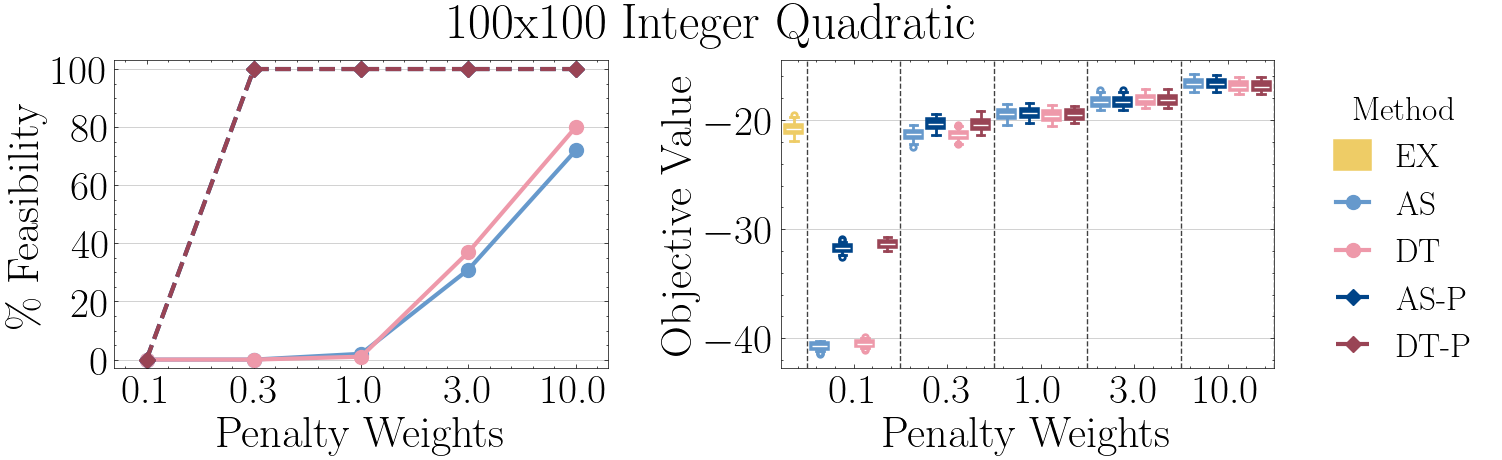

In [3]:
plot_penalty(problem="cq", size=100, penalties=[0.1, 0.3, 1.0, 3.0, 10.0], show_exact=True)

#### 1000x1000

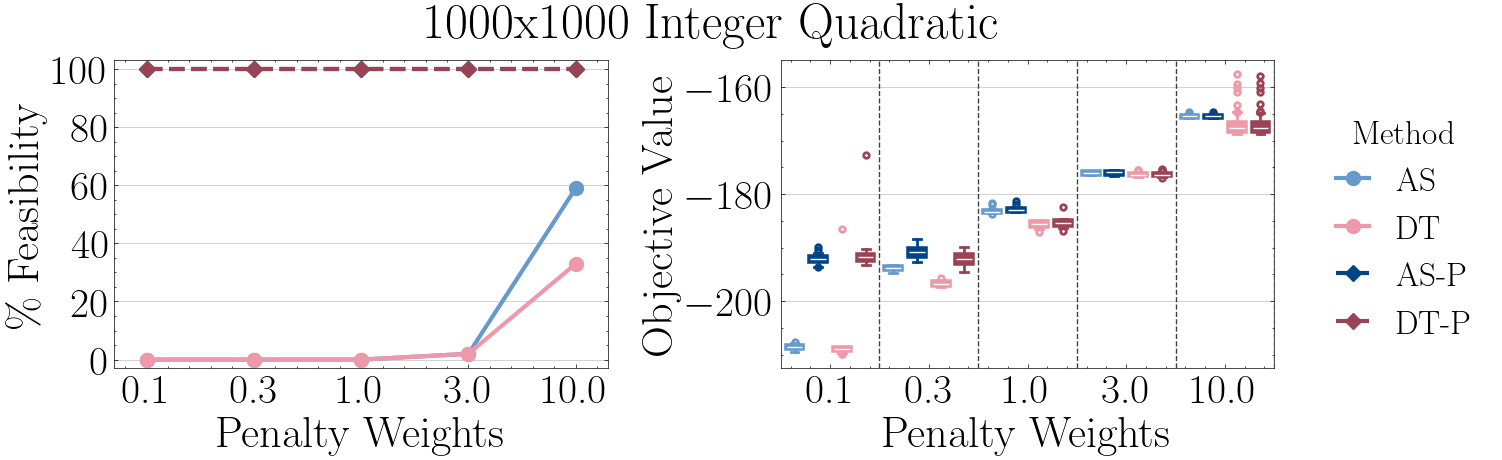

In [4]:
plot_penalty(problem="cq", size=1000, penalties=[0.1, 0.3, 1.0, 3.0, 10.0])

### Integer Non-Convex

#### 100x100

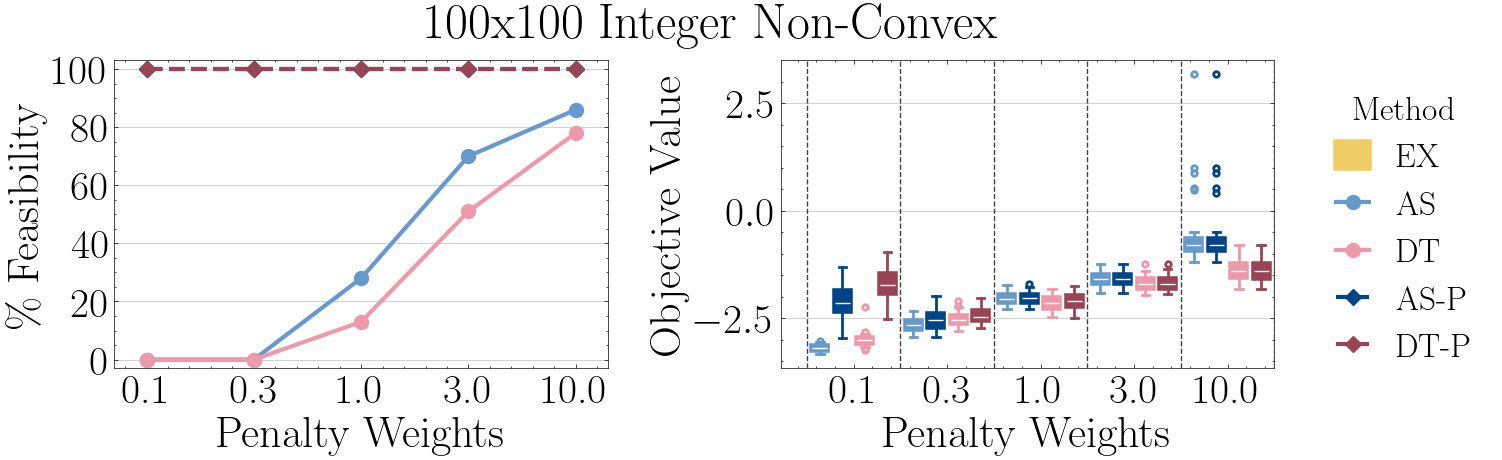

In [5]:
plot_penalty(problem="nc", size=100, penalties=[0.1, 0.3, 1.0, 3.0, 10.0], show_exact=True)

#### 1000x1000

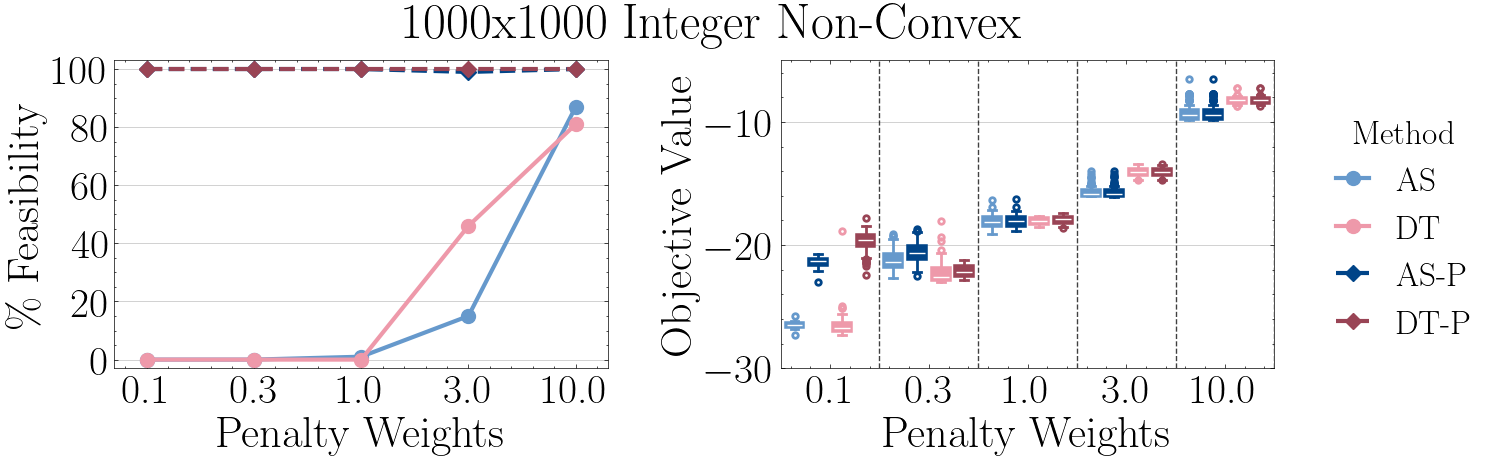

In [6]:
plot_penalty(problem="nc", size=1000, penalties=[0.1, 0.3, 1.0, 3.0, 10.0], ylim=(-30, -5))

### Mixed-Integer Rosenbrock

#### 200x4

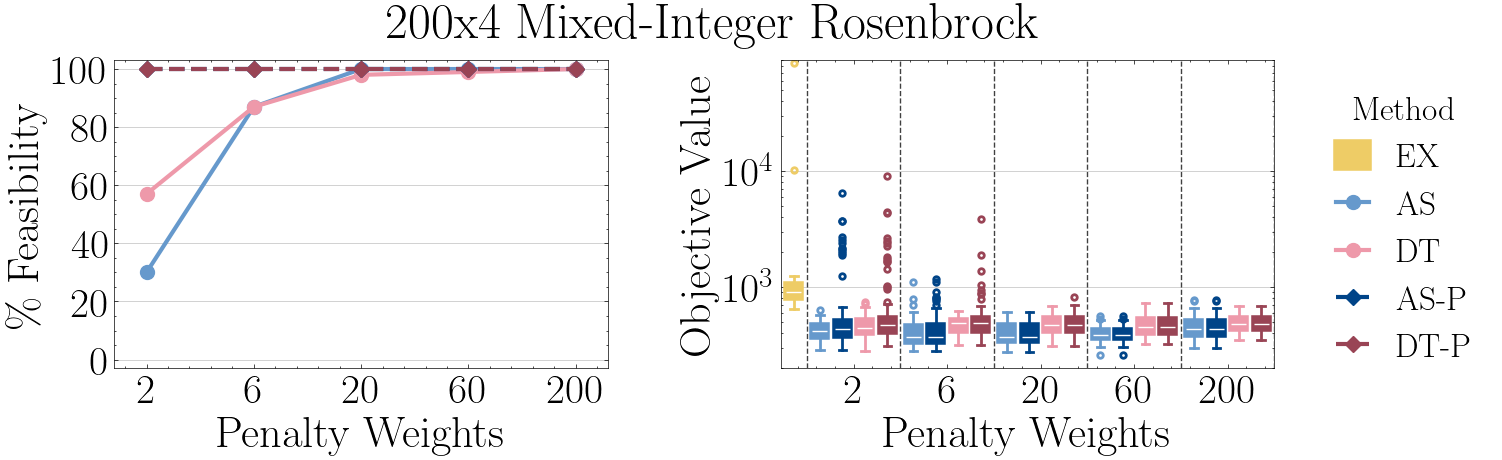

In [7]:
plot_penalty(problem="rb", size=100, penalties=[2, 6, 20, 60, 200], ylim=(2e2, 9e4), show_exact=True)

#### 2000x4

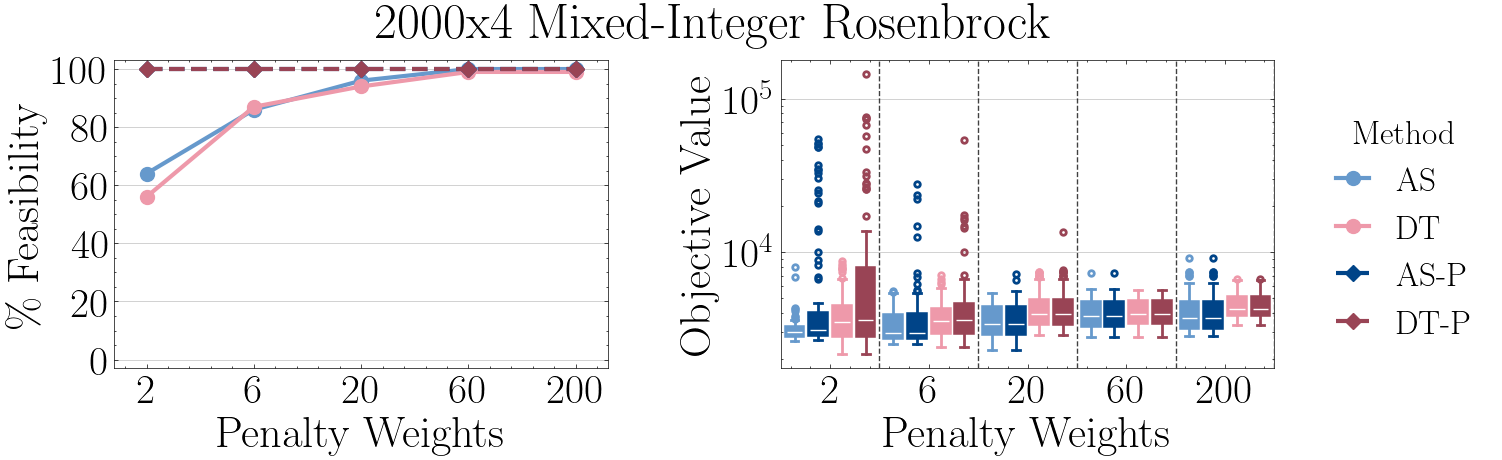

In [8]:
plot_penalty(problem="rb", size=1000, penalties=[2, 6, 20, 60, 200])